<div class="alert alert-block alert-success">
<h1>ASD Train, Test and Tune on Custom Dataset (with MNE)</h1>
</div>

# Benchmark performance by training model with different test pairs on whole night EEG recordings 

Some helpers

In [ ]:
in_colab = 'google.colab' in str(get_ipython())
print('Running in Colab' if in_colab else 'Not running in CoLab')

class StopExecution(Exception):
    def _render_traceback_(self):
        return []

def StopExecutionInColab():
  if in_colab:
    raise StopExecution

def StopExecutionNotInColab():
  if not in_colab:
    raise StopExecution

# StopExecutionInColab()

Not running in CoLab


# Install dependencies

Installing the braindecode with pip

Installing MNE-Python
https://pypi.org/project/mne/

Install torchinfo

In [2]:
StopExecutionNotInColab()

#!pip install braindecode
!pip install braindecode==0.7

!pip install mne

!pip install torchinfo

StopExecution: 

In [ ]:
USE_GPU = True
if USE_GPU:
    !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130
else:
    !pip install torch

In [2]:
# %matplotlib inline
import os
import os.path as op
import mne
import numpy as np
import pandas as pd
import torch
from braindecode.util import set_random_seeds

# Print Information PyTorch
print(f"Torch Version: {torch.__version__}")

# Set up GPU if it is there
cuda = torch.cuda.is_available()  # check if GPU is available, if True chooses to use it
device = torch.device("cuda") if cuda else "cpu"
print("GPU is", "AVAILABLE" if cuda else "NOT AVAILABLE")
if cuda:
    torch.backends.cudnn.benchmark = True
seed = 20200220
set_random_seeds(seed=seed, cuda=cuda)

Torch Version: 2.10.0+cu130
GPU is AVAILABLE


C:\Development\anya_diploma\venv\Lib\site-packages\braindecode\util.py:51: UserWarning: torch.backends.cudnn.benchmark was set to True which may results in lack of reproducibility. In some cases to ensure reproducibility you may need to set torch.backends.cudnn.benchmark to False.
  warn(


In [3]:
device

device(type='cuda')

### Init data storage

Mounting Google Drive to access the records...

In [4]:
if in_colab:
  from google.colab import drive
  drive.mount('/content/gdrive')

In [5]:
if in_colab:
  base_dir = '/content/gdrive/MyDrive/ASD/'
else:
  base_dir = './'

data_dir = op.join(base_dir, 'data') # Path to the raw EEG Data folder
dataset_dir = op.join(data_dir, 'dataset') # Path to Braindecode BaseConcatDataset
windows_dataset_dir = op.join(data_dir, 'windows_dataset') # Path to the windows_dataset folder\

# !ls {data_dir}

### Copy data from Google Drive to local filesystem

In [6]:
if in_colab:
    drive_data_dir = '/content/data'
local_data_dir = './data'

local_windows_dataset_dir = op.join(local_data_dir if not in_colab else drive_data_dir, 'windows_dataset_2')
#
# %cp -av {windows_dataset_dir} {local_windows_dataset_dir}

### Load dataset

In [7]:
if in_colab:
    windows_dataset_dir = '/content/gdrive/MyDrive/ASD/data/windows_dataset_2'

In [ ]:
from braindecode.datautil import load_concat_dataset

windows_dataset = load_concat_dataset(
    path=local_windows_dataset_dir,
#    preload=True
    preload=False
)

windows_dataset.description

### Investigate windows_dataset

In [9]:
len(windows_dataset)

134546

In [ ]:
print(windows_dataset.datasets[0].__dir__())
print(windows_dataset.datasets[0].description)

In [14]:
for ds in windows_dataset.datasets:
    print(f"n_channels = {len(ds.windows.info['ch_names'])}, ch_names = {ds.windows.info['ch_names']}")

n_channels = 21, ch_names = ['EEG Fp1-A1', 'EEG Fp2-A1', 'EEG F7-A1', 'EEG F3-A1', 'EEG Fz-A1', 'EEG F4-A1', 'EEG F8-A1', 'EEG T3-A1', 'EEG C3-A1', 'EEG Cz-A1', 'EEG C4-A1', 'EEG T4-A1', 'EEG T5-A1', 'EEG P3-A1', 'EEG Pz-A1', 'EEG P4-A1', 'EEG T6-A1', 'EEG O1-A1', 'EEG O2-A1', 'EEG A2-A1', 'EEG A1-N']
n_channels = 21, ch_names = ['EEG Fp1-A1', 'EEG Fp2-A1', 'EEG F7-A1', 'EEG F3-A1', 'EEG Fz-A1', 'EEG F4-A1', 'EEG F8-A1', 'EEG T3-A1', 'EEG C3-A1', 'EEG Cz-A1', 'EEG C4-A1', 'EEG T4-A1', 'EEG T5-A1', 'EEG P3-A1', 'EEG Pz-A1', 'EEG P4-A1', 'EEG T6-A1', 'EEG O1-A1', 'EEG O2-A1', 'EEG A2-A1', 'EEG A1-N']
n_channels = 21, ch_names = ['EEG Fp1-A1', 'EEG Fp2-A1', 'EEG F7-A1', 'EEG F3-A1', 'EEG Fz-A1', 'EEG F4-A1', 'EEG F8-A1', 'EEG T3-A1', 'EEG C3-A1', 'EEG Cz-A1', 'EEG C4-A1', 'EEG T4-A1', 'EEG T5-A1', 'EEG P3-A1', 'EEG Pz-A1', 'EEG P4-A1', 'EEG T6-A1', 'EEG O1-A1', 'EEG O2-A1', 'EEG A2-A1', 'EEG A1-N']
n_channels = 21, ch_names = ['EEG Fp1-A1', 'EEG Fp2-A1', 'EEG F7-A1', 'EEG F3-A1', 'EEG Fz-

In [15]:
windows_dataset.description.groupby('label').groups

{'autism': [0, 1, 2, 3, 4, 5, 6, 7], 'norm': [8, 9, 10, 11, 12, 13]}

### Prepare dataset and load data

Some `windows_dataset` stats per subject

In [ ]:
samples_set = set()
for subject_id, group in windows_dataset.description.groupby('subject'):
    samples = sum([len(windows_dataset.datasets[i]) for i in group.index.tolist()])
    print(f"subject={subject_id}: labels={group.loc[:,'label'].tolist()} files={ group.loc[:,'file'].tolist()} ds_idxs={group.index.tolist()} samples={samples} {'-- DUPLICATED?' if samples in samples_set else ''}")
    samples_set.add(samples)


In [ ]:
from typing import Any

from braindecode.preprocessing import Preprocessor, preprocess
from braindecode.datasets import BaseDataset, BaseConcatDataset
import psutil

try:
    from data_anonymization import anonymize_data, anonymize_dataset, deanonymize_data
except ImportError:
    def anonymize_data(value: Any) -> Any:
        return value

    def deanonymize_data(value: Any) -> Any:
        return value

    def anonymize_dataset(dataset: Any) -> Any:
        return dataset


# Real filenames should not be written here.
# Use anonymized/public file values if exclusions are still needed.
exclude_subjects = set()


def public_name(value: Any) -> str:
    """Return an anonymized string for display."""
    return str(anonymize_data(value))


def get_safe_record_name(description: pd.DataFrame, i: int) -> str:
    """Get an anonymized record name from a dataset description row."""
    row = description.loc[i]

    if "public_id" in row and pd.notna(row["public_id"]):
        return public_name(row["public_id"])

    if "file" in row and pd.notna(row["file"]):
        return public_name(row["file"])

    return public_name(f"record_{i:03d}")


# Anonymize description view if supported by your helper.
try:
    windows_dataset = anonymize_dataset(windows_dataset)
except Exception:
    pass


ch_names = set(windows_dataset.datasets[0].windows.info["ch_names"])

ds_idxs = []
for i, ds in enumerate(windows_dataset.datasets):
    record_name = get_safe_record_name(windows_dataset.description, i)

    if any(ch.endswith("-A2") for ch in ds.windows.info["ch_names"]):
        print(f"Warning: {record_name} has channel with name that ends with '-A2'")
        continue

    if len(ds.windows.info["ch_names"]) != 21:
        print(f"Warning: {record_name} number of channels not equal to 21")
        continue

    file_value = windows_dataset.description.loc[i, "file"]
    if anonymize_data(file_value) in exclude_subjects:
        print(f"Warning: {record_name} in excluded subjects")
        continue

    ch_names = ch_names & set(ds.windows.info["ch_names"])

    print(
        f"{record_name}: "
        f"n_channels = {len(ds.windows.info['ch_names'])}, "
        f"ch_names = {ds.windows.info['ch_names']}"
    )

    ds_idxs.append(i)

ch_names = list(ch_names)

print(f"\nn_channels = {len(ch_names)} ch_names = {ch_names}")
print(f"\nds_idxs = {ds_idxs}")

dataset_filtered = BaseConcatDataset([windows_dataset.datasets[i] for i in ds_idxs])

print("\n")
display(dataset_filtered.description)
print("\n")


def merge_alternatively(lst1, lst2):
    if not lst1:
        return lst2
    if not lst2:
        return lst1
    return [lst1[0], lst2[0]] + merge_alternatively(lst1[1:], lst2[1:])


groups = dataset_filtered.description.groupby("label").groups
load_i = merge_alternatively(list(groups["autism"]), list(groups["norm"]))

for i in load_i:
    if psutil.virtual_memory().available < 3 * 1024 * 1024 * 1024:
        print("out of memory")
        break

    file_ds = dataset_filtered.datasets[i]
    record_name = get_safe_record_name(dataset_filtered.description, i)

    if file_ds.windows.preload:
        continue

    ram_0 = psutil.virtual_memory().available
    file_ds.windows.load_data()
    ram_inc = ram_0 - psutil.virtual_memory().available

    print(
        f"datasets[{i}] ({record_name}): "
        f"Virtual memory {ram_inc} used to load {len(file_ds)} samples, "
        f"{ram_inc / len(file_ds)} bytes/sample"
    )
    print(f"still available: {psutil.virtual_memory().available / (1024 * 1024 * 1024)} GB")


for i, file_ds in enumerate(dataset_filtered.datasets):
    record_name = get_safe_record_name(dataset_filtered.description, i)
    print(
        f"datasets[{i}] ({record_name}): "
        f"preload={file_ds.windows.preload}, "
        f"n_channels={len(file_ds.windows.info['ch_names'])}"
    )


# Use only loaded part.
dataset_loaded = BaseConcatDataset([
    file_ds for file_ds in dataset_filtered.datasets
    if file_ds.windows.preload
])

try:
    dataset_loaded = anonymize_dataset(dataset_loaded)
except Exception:
    pass

print("\n")
display(dataset_loaded.description)

Some dataset stats per subject

In [ ]:
for subject_id, group in dataset_loaded.description.groupby('subject'):
    samples = [len(dataset_loaded.datasets[i]) for i in group.index.tolist()]
    print(f"subject={subject_id}: labels={group.loc[:,'label'].tolist()} files={ group.loc[:,'file'].tolist()} ds_idxs={group.index.tolist()} samples={samples}")

In [20]:
n_classes = 2
# Extract number of chans and time steps from dataset
n_channels = dataset_loaded[0][0].shape[0]
input_window_samples = dataset_loaded[0][0].shape[1]

print(f"len(dataset) = {len(dataset_loaded)}, n_classes = {n_classes}, n_channels = {n_channels}, input_window_samples = {input_window_samples}")

len(dataset) = 84713, n_classes = 2, n_channels = 21, input_window_samples = 1000


### Plot random samples

In [ ]:
import bisect
import itertools
from typing import Iterable

def dataset_idx_from_sample_idx(dataset, idx):
   return bisect.bisect_right(dataset.cumulative_sizes, idx)

def dataset_desc_from_sample_idx(dataset, idx, key='subject'):
   return dataset.description.iloc[dataset_idx_from_sample_idx(dataset, idx)][key]

def dataset_idx_range_from_ds_idx(dataset, ds_idx):
   return range(dataset.cumulative_sizes[ds_idx-1] if ds_idx > 0 else 0, dataset.cumulative_sizes[ds_idx])

def dataset_idxs_from_subject(dataset, subject_id):
   if isinstance(subject_id, Iterable):
     ds_idx = [i for id in subject_id for i in list(dataset.description.groupby('subject').groups[id])]
   else:
     ds_idx = list(dataset.description.groupby('subject').groups[subject_id])
   return itertools.chain(*[dataset_idx_range_from_ds_idx(dataset, i) for i in ds_idx])


n_channels = 21
input_window_samples = 1000
ch_names = ['EEG Fp1-A1', 'EEG Fp2-A1', 'EEG F7-A1', 'EEG F3-A1', 'EEG Fz-A1', 'EEG F4-A1', 'EEG F8-A1', 'EEG T3-A1', 'EEG C3-A1', 'EEG Cz-A1', 'EEG C4-A1', 'EEG T4-A1', 'EEG T5-A1', 'EEG P3-A1', 'EEG Pz-A1', 'EEG P4-A1', 'EEG T6-A1', 'EEG O1-A1', 'EEG O2-A1', 'EEG A2-A1', 'EEG A1-N']


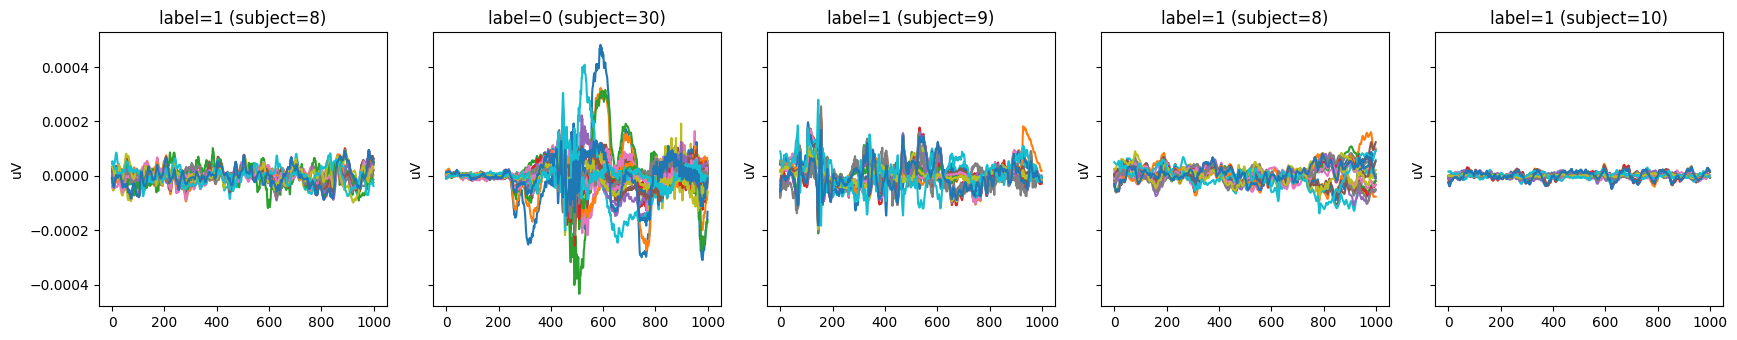

In [22]:
import random
import matplotlib.pyplot as plt

x, y, window_ind = dataset_loaded[0]
n_channels, input_window_samples = x.shape
print(f"n_channels = {n_channels}")
print(f"input_window_samples = {input_window_samples}")
print(f"ch_names = {dataset_loaded.datasets[0].windows.info['ch_names']}")


max_i = 4
fig, axs = plt.subplots(1, max_i + 1, figsize=(3.5 * (max_i + 1), 3.5),
                           sharex=True, sharey=True)

shuffle_idxs = list(range(len(dataset_loaded)))
random.shuffle(shuffle_idxs)
for i, idx in enumerate(shuffle_idxs):
    x, y, window_ind = dataset_loaded[idx]
    subject = dataset_desc_from_sample_idx(dataset_loaded, idx, key='subject')
    axs[i].plot(x.T, label = ch_names)
    axs[i].set_title(f"label={y} (subject={subject})")
    axs[i].set_ylabel("uV")
    # axs[i].legend()
    if i == max_i:
        break

fig.tight_layout()

# Create model

In [ ]:
!pip install torchinfo

In [23]:
from torchinfo import summary
from braindecode.models import ShallowFBCSPNet
from braindecode.models import EEGNetv4
from torch import nn

# ==== REFACTORED INTO A FUNCTION ====
def define_eegnet_model(n_channels, input_windows_samples, device, debug=False) -> EEGNetv4:
    """
    
    """
    n_classes = 2
    # Extract number of chans and time steps from dataset
    # n_channels = windows_dataset[0][0].shape[0]
    # input_window_samples =  windows_dataset[0][0].shape[1]
    if debug:
        print(f"n_classes = {n_classes}, n_channels = {n_channels}, input_window_samples = {input_window_samples}")

    # model = ShallowFBCSPNet(
    #     n_channels,
    #     n_classes,
    #     input_window_samples=input_window_samples,
    #     final_conv_length="auto",
    # )

    model = EEGNetv4(in_chans=n_channels, n_classes=n_classes, input_window_samples=input_window_samples)
    # For  braindecode==0.8.1
    # model = EEGNetv4(n_chans=n_channels, n_outputs=n_classes, n_times=input_window_samples)

    # Send model to GPU 
    if device != "cpu":
        print("Sending model to GPU")
        model.cuda(device)
        print(f"Model parameters are on the GPU: {next(model.parameters()).is_cuda}")

    # Describe the model
    # batch_size = 64
    # summary(model, input_size=(batch_size, n_channels, input_window_samples))
    return model

def glorot_weight_zero_bias(model):
    """Initalize parameters of all modules by initializing weights with
    glorot
     uniform/xavier initialization, and setting biases to zero. Weights from
     batch norm layers are set to 1.

    Parameters
    ----------
    model: Module
    """
    for module in model.modules():
        if hasattr(module, "weight"):
            if "BatchNorm" not in module.__class__.__name__:
                nn.init.xavier_uniform_(module.weight, gain=1)
            else:
                nn.init.constant_(module.weight, 1)
        if hasattr(module, "bias"):
            if module.bias is not None:
                nn.init.constant_(module.bias, 0)

In [24]:
import random
from torch.utils.data import Subset
def random_split(dataset, val_size=0.2, test_size=0.2, shuffle=True):
    indices = list(range(0, len(dataset)))
    if shuffle:
        random.shuffle(indices)
    
    test_indices = indices[:int(len(indices)*test_size)]
    val_indices = indices[len(test_indices):int(len(test_indices)+len(indices)*val_size)]
    train_indices = indices[len(test_indices)+len(val_indices):]

    train_subset = Subset(dataset, train_indices)
    val_subset = Subset(dataset, val_indices)
    test_set = Subset(dataset, test_indices)
    return train_subset, val_subset, test_set


# Split train, validation and test based on subjects
def subj_split(dataset, val_size=0.2, test_subject=[1, 16], shuffle=True):

    test_indices = list(dataset_idxs_from_subject(dataset, test_subject))
    print(f"len test indices: {len(test_indices)}")
    if shuffle:
        random.shuffle(test_indices)

    indices = list(set(range(0, len(dataset))) - set(test_indices))
    if shuffle:
       random.shuffle(indices)
    val_indices = indices[:int(len(indices)*val_size)]
    train_indices = indices[len(val_indices):]
    print(f"len val indices: {len(val_indices)}, len train indices: {len(train_indices)}")

    train_subset = Subset(dataset, train_indices)
    # print(f"train_subset: {train_subset}")
    # for item in train_subset:
    #     print(f"{item}")
    val_subset = Subset(dataset, val_indices)
    test_set = Subset(dataset, test_indices)
    return train_subset, val_subset, test_set

## Experiment on all test pairs

In [ ]:
!pip install tensorboard

In [ ]:
import os, time
import itertools
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datetime import datetime
from torch.utils.tensorboard import SummaryWriter
from skorch.helper import SliceDataset, predefined_split
from skorch.callbacks import LRScheduler, Checkpoint, TrainEndCheckpoint
from skorch.callbacks import TensorBoard
from braindecode import EEGClassifier
from braindecode.models import EEGNetv4
import mne

# --- Make sure these exist from your notebook ---
# - subj_split(dataset, val_size=0.2, test_subject=[...], shuffle=True)
# - glorot_weight_zero_bias(model)
# - dataset_desc_from_sample_idx(dataset, i, key='subject')   (used earlier)
# - dataset_idxs_from_subject(dataset, test_subject)          (used inside subj_split)

RESULTS_CSV = "pair_results.csv"
os.makedirs("runs", exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)

def load_existing_pairs(results_csv=RESULTS_CSV):
    """Return (df, set_of_pairs_successfully_done)."""
    if os.path.exists(results_csv):
        df = pd.read_csv(results_csv)
        if "status" not in df.columns:
            df["status"] = "ok"
        ok_df = df[df["status"] == "ok"]
        done = set(zip(ok_df["norm_subject"].astype(int), ok_df["autism_subject"].astype(int)))
        return df, done
    else:
        cols = [
            "timestamp",
            "norm_subject",
            "autism_subject",
            "test_subjects",
            "n_train",
            "n_val",
            "n_test",
            "val_acc",
            "test_acc",
            "lr",
            "weight_decay",
            "batch_size",
            "n_epochs",
            "tb_dir",
            "ckpt_dir",
            "status",
            "notes",
        ]
        return pd.DataFrame(columns=cols), set()


df_results, done_pairs = load_existing_pairs()
print("Already done pairs:", sorted(done_pairs))


def run_one_pair(
    dataset,
    norm_subj,
    autism_subj,
    lr=0.0005,
    weight_decay=0.0,
    batch_size=64,
    n_epochs=25,
    device="cuda",
):
    """
    Runs exactly your training logic for one (normal, autism) pair:
      - subj_split(..., test_subject=[autism_subj, norm_subj])
      - EEGNetv4
      - EEGClassifier with same callbacks and scoring
      - Returns dict row to append to CSV
    """
    pair_ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    test_subject = [autism_subj, norm_subj]

    # Split (same logic)
    train_subset, val_subset, test_set = subj_split(dataset, 0.2, test_subject, True)

    # Get test subjects sanity
    test_subjects = set()
    for i in test_set.indices:
        test_subjects.add(dataset_desc_from_sample_idx(dataset, i, key='subject'))

    # Build model (same logic)
    n_classes = 2
    n_channels = dataset[0][0].shape[0]
    input_window_samples = dataset[0][0].shape[1]

    model = define_eegnet_model(n_channels, input_window_samples, device=device, debug=True) #EEGNetv4(in_chans=n_channels, n_classes=n_classes, input_window_samples=input_window_samples)
    if device != "cpu":
        # model.cuda(device)
        print(f"Model parameters are on the GPU: {next(model.parameters()).is_cuda}")
    # TensorBoard
    tb_dir = f"runs/train_{pair_ts}_norm{norm_subj}_aut{autism_subj}"
    writer = SummaryWriter(tb_dir)

    # Checkpoints per pair (so they don’t overwrite)
    ckpt_dir = f"./checkpoints/pair_norm{norm_subj}_aut{autism_subj}_{pair_ts}"
    os.makedirs(ckpt_dir, exist_ok=True)

    monitor = lambda net: all(net.history[-1, ('train_loss_best', 'valid_loss_best')])
    cp = Checkpoint(dirname=ckpt_dir, monitor=monitor)
    train_end_cp = TrainEndCheckpoint(dirname=ckpt_dir)

    clf = EEGClassifier(
        model,
        criterion=torch.nn.NLLLoss,
        optimizer=torch.optim.AdamW,
        train_split=predefined_split(val_subset),
        optimizer__lr=lr,
        optimizer__weight_decay=weight_decay,
        batch_size=batch_size,
        callbacks=[
            "accuracy",
            "f1_micro",
            ("lr_scheduler", LRScheduler("CosineAnnealingLR", T_max=n_epochs - 1)),
            ("cp", cp),
            ("train_end_cp", train_end_cp),
            ("tb", TensorBoard(writer)),
        ],
        device=device,
        compile=False,
    )#         iterator_train__num_workers=4,
        # iterator_valid__num_workers=4,
        # iterator_train__multiprocessing_context="fork",
        # iterator_valid__multiprocessing_context="fork",
        #         use_caching=True,
        # iterator_train__pin_memory=True,
        # iterator_valid__pin_memory=True
    # Init weights (same logic)
    glorot_weight_zero_bias(model)

    # Train (same logic)
    with mne.use_log_level(False):
        # X_train = SliceDataset(train_subset, idx=0)#np.array(list())
        # X_train = torch.stack([item for item in X_train]).to(device)
        y_train = np.array(list(SliceDataset(train_subset, idx=1)))#np.array(list())
        # y_train = torch.stack([item for item in y_train]).to(device)
        # y_train = torch.from_numpy(np.array(list(SliceDataset(train_subset, idx=1)))).to(device) #torch.stack
        clf.fit(train_subset, y=y_train, epochs=n_epochs)

    # Score (same logic)
    y_val = np.array([yy for yy in SliceDataset(val_subset, idx=1)])
    val_acc = clf.score(val_subset, y=y_val)

    y_test = np.array([yy for yy in SliceDataset(test_set, idx=1)])
    test_acc = clf.score(test_set, y=y_test)

    # Cleanup TB writer
    writer.flush()
    writer.close()

    # Free GPU RAM between runs
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    row = {
        "timestamp": pair_ts,
        "norm_subject": int(norm_subj),
        "autism_subject": int(autism_subj),
        "test_subjects": str(sorted(list(test_subjects))),
        "n_train": int(len(train_subset)),
        "n_val": int(len(val_subset)),
        "n_test": int(len(test_set)),
        "val_acc": float(val_acc),
        "test_acc": float(test_acc),
        "lr": float(lr),
        "weight_decay": float(weight_decay),
        "batch_size": int(batch_size),
        "n_epochs": int(n_epochs),
        "tb_dir": tb_dir,
        "ckpt_dir": ckpt_dir,
        "status": "ok",
        "notes": "",
    }
    return row


Already done pairs: []


In [ ]:
# save array pointers
# dataset_unfiltered = dataset 
# dataset = dataset_filtered

In [26]:
# Check if a CUDA-enabled GPU is available
print(f"CUDA Available: {torch.cuda.is_available()}")

# Print the number of available GPUs
print(f"GPU Count: {torch.cuda.device_count()}")

# Print the name of the first GPU (if available)
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

CUDA Available: True
GPU Count: 1
GPU Name: NVIDIA GeForce RTX 3060


In [30]:
normal_subjects = [24, 30, 31]
autism_subjects = [1, 2, 3, 4, 8, 9, 10]

# Optional sanity: keep only those that exist in the dataset
available_subjects = sorted(dataset_loaded.description["subject"].unique().tolist())
normal_subjects = [s for s in normal_subjects if s in available_subjects]
autism_subjects = [s for s in autism_subjects if s in available_subjects]

print("Available subjects:", available_subjects)
print("Normal (filtered):", normal_subjects)
print("Autism (filtered):", autism_subjects)

df_results, done_pairs = load_existing_pairs()
all_pairs = list(itertools.product(normal_subjects, autism_subjects))
print(f"Total pairs: {len(all_pairs)}")
print("Pairs:", all_pairs)

# Hyperparams (same as your notebook cell)
lr = 0.0005
weight_decay = 0.0
batch_size = 64
n_epochs = 25

for norm_subj, autism_subj in all_pairs:
    if (norm_subj, autism_subj) in done_pairs:
        print(f"SKIP done: norm={norm_subj}, aut={autism_subj}")
        continue

    print(f"\n=== RUN pair: norm={norm_subj} vs aut={autism_subj} ===")
    try:
        row = run_one_pair(
            dataset=dataset_loaded,
            norm_subj=norm_subj,
            autism_subj=autism_subj,
            lr=lr,
            weight_decay=weight_decay,
            batch_size=batch_size,
            n_epochs=n_epochs,
            device=device,   # uses your existing `device`
        )
        df_results = pd.concat([df_results, pd.DataFrame([row])], ignore_index=True)
        df_results.to_csv(RESULTS_CSV, index=False)
        done_pairs.add((norm_subj, autism_subj))

        print(f"OK: val_acc={row['val_acc']*100:.2f}%, test_acc={row['test_acc']*100:.2f}%")
        print(f"Saved -> {RESULTS_CSV}")

    except Exception as e:
        # Save failure row too (so you can see which pair crashed)
        fail_ts = datetime.now().strftime('%Y%m%d_%H%M%S')
        fail_row = {
            "timestamp": fail_ts,
            "norm_subject": int(norm_subj),
            "autism_subject": int(autism_subj),
            "test_subjects": str([int(autism_subj), int(norm_subj)]),
            "n_train": -1,
            "n_val": -1,
            "n_test": -1,
            "val_acc": np.nan,
            "test_acc": np.nan,
            "lr": float(lr),
            "weight_decay": float(weight_decay),
            "batch_size": int(batch_size),
            "n_epochs": int(n_epochs),
            "tb_dir": "",
            "ckpt_dir": "",
            "status": "failed",
            "notes": repr(e),
        }
        df_results = pd.concat([df_results, pd.DataFrame([fail_row])], ignore_index=True)
        df_results.to_csv(RESULTS_CSV, index=False)
        print(f"FAILED pair norm={norm_subj}, aut={autism_subj}: {e}")

print("\nDONE. Results file:", RESULTS_CSV)
display(df_results.tail(20))


Available subjects: [1, 2, 4, 8, 9, 10, 24, 30, 31]
Normal (filtered): [24, 30, 31]
Autism (filtered): [1, 2, 4, 8, 9, 10]
Total pairs: 18
Pairs: [(24, 1), (24, 2), (24, 4), (24, 8), (24, 9), (24, 10), (30, 1), (30, 2), (30, 4), (30, 8), (30, 9), (30, 10), (31, 1), (31, 2), (31, 4), (31, 8), (31, 9), (31, 10)]

=== RUN pair: norm=24 vs aut=1 ===
len test indices: 13704
len val indices: 14201, len train indices: 56808
n_classes = 2, n_channels = 21, input_window_samples = 1000
Sending model to GPU
Model parameters are on the GPU: True
Model parameters are on the GPU: True
  epoch    train_accuracy    train_f1_micro    train_loss    valid_accuracy    valid_f1_micro    valid_loss    cp      lr      dur
-------  ----------------  ----------------  ------------  ----------------  ----------------  ------------  ----  ------  -------
      1            0.5965            0.5965        0.6759            0.5944            0.5944        2.5721     +  0.0005  55.5533
      2            0.5965    

,timestamp,norm_subject,autism_subject,test_subjects,n_train,n_val,n_test,val_acc,test_acc,lr,weight_decay,batch_size,n_epochs,tb_dir,ckpt_dir,status,notes
0,20260228_014951,24,1,"[np.int64(1), np.int64(24)]",56808,14201,13704,0.93585,0.319031,0.0005,0.0,64,25,runs/train_20260228_014951_norm24_aut1,./checkpoints/pair_norm24_aut1_20260228_014951,ok,
1,20260228_022050,24,2,"[np.int64(2), np.int64(24)]",55701,13925,15087,0.929838,0.305362,0.0005,0.0,64,25,runs/train_20260228_022050_norm24_aut2,./checkpoints/pair_norm24_aut2_20260228_022050,ok,
2,20260228_030117,24,4,"[np.int64(4), np.int64(24)]",52810,13202,18701,0.949099,0.457141,0.0005,0.0,64,25,runs/train_20260228_030117_norm24_aut4,./checkpoints/pair_norm24_aut4_20260228_030117,ok,
3,20260228_033943,24,8,"[np.int64(8), np.int64(24)]",50796,12699,21218,0.886054,0.712744,0.0005,0.0,64,25,runs/train_20260228_033943_norm24_aut8,./checkpoints/pair_norm24_aut8_20260228_033943,ok,
4,20260228_041643,24,9,"[np.int64(9), np.int64(24)]",55400,13849,15464,0.931331,0.635605,0.0005,0.0,64,25,runs/train_20260228_041643_norm24_aut9,./checkpoints/pair_norm24_aut9_20260228_041643,ok,
5,20260228_045657,24,10,"[np.int64(10), np.int64(24)]",52669,13167,18877,0.909243,0.707157,0.0005,0.0,64,25,runs/train_20260228_045657_norm24_aut10,./checkpoints/pair_norm24_aut10_20260228_045657,ok,
6,20260228_053517,30,1,"[np.int64(1), np.int64(30)]",49320,12330,23063,0.937145,0.238998,0.0005,0.0,64,25,runs/train_20260228_053517_norm30_aut1,./checkpoints/pair_norm30_aut1_20260228_053517,ok,
7,20260228_061115,30,2,"[np.int64(2), np.int64(30)]",48214,12053,24446,0.959595,0.252107,0.0005,0.0,64,25,runs/train_20260228_061115_norm30_aut2,./checkpoints/pair_norm30_aut2_20260228_061115,ok,
8,20260228_064624,30,4,"[np.int64(4), np.int64(30)]",45323,11330,28060,0.929921,0.269993,0.0005,0.0,64,25,runs/train_20260228_064624_norm30_aut4,./checkpoints/pair_norm30_aut4_20260228_064624,ok,
9,20260228_071934,30,8,"[np.int64(8), np.int64(30)]",43309,10827,30577,0.908839,0.322824,0.0005,0.0,64,25,runs/train_20260228_071934_norm30_aut8,./checkpoints/pair_norm30_aut8_20260228_071934,ok,


Loaded 18 rows, ok=18


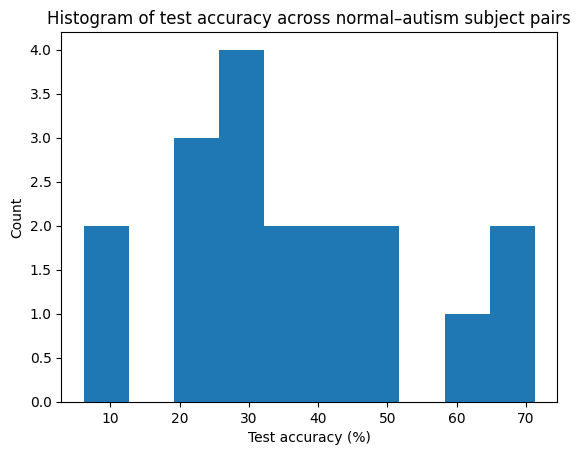

,norm_subject,autism_subject,val_acc,test_acc
3,24,8,0.886054,0.712744
5,24,10,0.909243,0.707157
4,24,9,0.931331,0.635605
17,31,10,0.895132,0.475557
2,24,4,0.949099,0.457141
14,31,4,0.922819,0.410179
15,31,8,0.901318,0.392169
16,31,9,0.923978,0.357219
9,30,8,0.908839,0.322824
0,24,1,0.935850,0.319031


,norm_subject,autism_subject,val_acc,test_acc
9,30,8,0.908839,0.322824
0,24,1,0.935850,0.319031
1,24,2,0.929838,0.305362
10,30,9,0.949157,0.278895
8,30,4,0.929921,0.269993
11,30,10,0.944931,0.252762
7,30,2,0.959595,0.252107
6,30,1,0.937145,0.238998
12,31,1,0.939566,0.100640
13,31,2,0.919693,0.061595


In [31]:
df = pd.read_csv(RESULTS_CSV)

# Keep only successful runs with numeric test_acc
df_ok = df[(df["status"] == "ok") & (df["test_acc"].notna())].copy()

print(f"Loaded {len(df)} rows, ok={len(df_ok)}")

plt.figure()
plt.hist(df_ok["test_acc"] * 100, bins=10)
plt.xlabel("Test accuracy (%)")
plt.ylabel("Count")
plt.title("Histogram of test accuracy across normal–autism subject pairs")
plt.show()

# Optional: show best/worst pairs quickly
df_ok_sorted = df_ok.sort_values("test_acc", ascending=False)
display(df_ok_sorted[["norm_subject","autism_subject","val_acc","test_acc"]].head(10))
display(df_ok_sorted[["norm_subject","autism_subject","val_acc","test_acc"]].tail(10))


In [64]:
torch.cuda.empty_cache()

Loaded 15 rows, ok=15


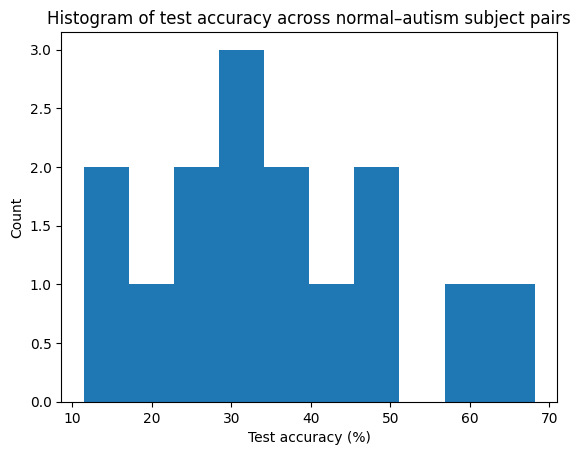

,norm_subject,autism_subject,val_acc,test_acc
3,24,8,0.886684,0.681780
4,24,9,0.942306,0.579928
13,31,8,0.897904,0.476142
2,24,3,0.931450,0.468317
12,31,3,0.932285,0.399979
7,30,3,0.937423,0.349537
8,30,8,0.929990,0.342316
14,31,9,0.911101,0.317792
6,30,2,0.925828,0.298617
5,30,1,0.941849,0.287907


,norm_subject,autism_subject,val_acc,test_acc
7,30,3,0.937423,0.349537
8,30,8,0.929990,0.342316
14,31,9,0.911101,0.317792
6,30,2,0.925828,0.298617
5,30,1,0.941849,0.287907
9,30,9,0.963016,0.281956
1,24,2,0.936302,0.263870
0,24,1,0.944652,0.192863
11,31,2,0.917016,0.152993
10,31,1,0.941836,0.114495


In [ ]:
df = pd.read_csv(RESULTS_CSV)

# Keep only successful runs with numeric test_acc
df_ok = df[(df["status"] == "ok") & (df["test_acc"].notna())].copy()

print(f"Loaded {len(df)} rows, ok={len(df_ok)}")

plt.figure()
plt.hist(df_ok["test_acc"] * 100, bins=10)
plt.xlabel("Test accuracy (%)")
plt.ylabel("Count")
plt.title("Histogram of test accuracy across normal–autism subject pairs")
plt.show()

# Optional: show best/worst pairs quickly
df_ok_sorted = df_ok.sort_values("test_acc", ascending=False)
display(df_ok_sorted[["norm_subject","autism_subject","val_acc","test_acc"]].head(10))
display(df_ok_sorted[["norm_subject","autism_subject","val_acc","test_acc"]].tail(10))


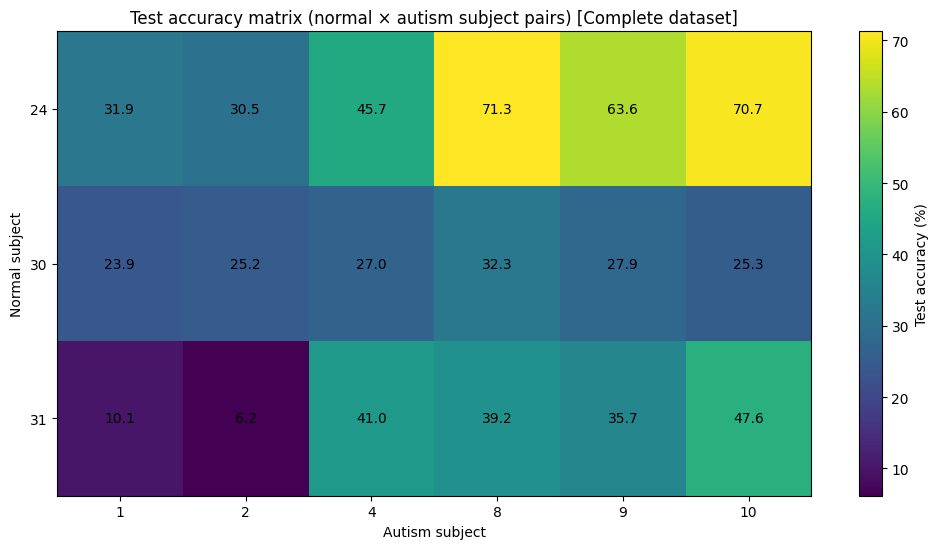

autism_subject,1,2,4,8,9,10
norm_subject,,,,,,
24,31.903094,30.536223,45.714133,71.274390,63.560528,70.715686
30,23.899753,25.210668,26.999287,32.282435,27.889457,25.276243
31,10.063999,6.159467,41.017902,39.216859,35.721885,47.555693


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load
df = pd.read_csv(RESULTS_CSV)

# Keep only successful runs
df_ok = df[(df["status"] == "ok") & (df["test_acc"].notna())].copy()

# Use your subject lists (or infer from df)
normal_subjects = sorted(df_ok["norm_subject"].unique().tolist())
autism_subjects = sorted(df_ok["autism_subject"].unique().tolist())

# Pivot into matrix (values in %)
mat = df_ok.pivot_table(
    index="norm_subject",
    columns="autism_subject",
    values="test_acc",
    aggfunc="mean"
) * 100.0

# Ensure consistent order
mat = mat.reindex(index=normal_subjects, columns=autism_subjects)

# ---- Plot as heatmap (matplotlib only) ----
plt.figure(figsize=(1.2*len(autism_subjects) + 3, 1.2*len(normal_subjects) + 2))
im = plt.imshow(mat.values, aspect="auto")  # no explicit colors
plt.colorbar(im, label="Test accuracy (%)")

plt.xticks(ticks=np.arange(len(autism_subjects)), labels=autism_subjects)
plt.yticks(ticks=np.arange(len(normal_subjects)), labels=normal_subjects)
plt.xlabel("Autism subject")
plt.ylabel("Normal subject")
plt.title("Test accuracy matrix (normal × autism subject pairs) [Complete dataset]")

# Annotate each cell with the number (or NA)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        val = mat.values[i, j]
        txt = "NA" if np.isnan(val) else f"{val:.1f}"
        plt.text(j, i, txt, ha="center", va="center")

plt.tight_layout()
plt.show()

display(mat)


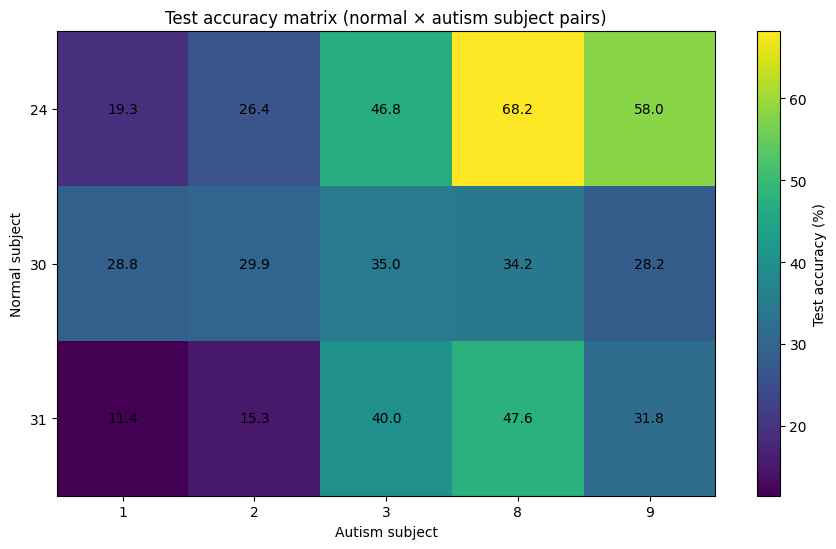

autism_subject,1,2,3,8,9
norm_subject,,,,,
24,19.286340,26.386956,46.831720,68.177962,57.992757
30,28.790704,29.861736,34.953671,34.231612,28.195625
31,11.449469,15.299321,39.997918,47.614227,31.779210


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load
df = pd.read_csv(RESULTS_CSV)

# Keep only successful runs
df_ok = df[(df["status"] == "ok") & (df["test_acc"].notna())].copy()

# Use your subject lists (or infer from df)
normal_subjects = sorted(df_ok["norm_subject"].unique().tolist())
autism_subjects = sorted(df_ok["autism_subject"].unique().tolist())

# Pivot into matrix (values in %)
mat = df_ok.pivot_table(
    index="norm_subject",
    columns="autism_subject",
    values="test_acc",
    aggfunc="mean"
) * 100.0

# Ensure consistent order
mat = mat.reindex(index=normal_subjects, columns=autism_subjects)

# ---- Plot as heatmap (matplotlib only) ----
plt.figure(figsize=(1.2*len(autism_subjects) + 3, 1.2*len(normal_subjects) + 2))
im = plt.imshow(mat.values, aspect="auto")  # no explicit colors
plt.colorbar(im, label="Test accuracy (%)")

plt.xticks(ticks=np.arange(len(autism_subjects)), labels=autism_subjects)
plt.yticks(ticks=np.arange(len(normal_subjects)), labels=normal_subjects)
plt.xlabel("Autism subject")
plt.ylabel("Normal subject")
plt.title("Test accuracy matrix (normal × autism subject pairs)")

# Annotate each cell with the number (or NA)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        val = mat.values[i, j]
        txt = "NA" if np.isnan(val) else f"{val:.1f}"
        plt.text(j, i, txt, ha="center", va="center")

plt.tight_layout()
plt.show()

display(mat)


## Re-try, but now with cross-validation

In [ ]:
subject_dict = { id: {'labels': group.loc[:,'label'].tolist(), 
                      'files': group.loc[:,'file'].tolist(),
                      'ds': list(group.index) } 
                      for id, group in dataset_loaded.description.groupby('subject') }
print(f'subject_dict = {subject_dict}\n')

for subject_id, subject_info in subject_dict.items():
  _test_indices = list(dataset_idxs_from_subject(dataset_loaded, subject_id))
  _test_set = Subset(dataset_loaded, _test_indices)  
  # score the Model after training (optional)
  _y_test = np.array([y for y in SliceDataset(_test_set, idx=1)])
  _test_acc = clf.score(_test_set, y=_y_test)
  print(f"Test subject={subject_id}: labels={subject_info['labels']} files={subject_info['files']} Test accuracy={(_test_acc * 100):.2f}%")

In [40]:
from skorch.helper import SliceDataset
from sklearn.model_selection import KFold
from sklearn.model_selection import LeaveOneGroupOut

# cv = 'KFold'
cv = 'LOSO' # Leave one Subject out

# train_subset_best, val_subset_best, test_set_best = subj_split(dataset_loaded, test_subject=[8, 24])
# model_eegnet = define_eegnet_model(n_channels, input_windows_samples, device)

def merge_train_val(train_subset, val_subset):
    
    train_indices = train_subset.indices + val_subset.indices
    # train_indices = train_indices[:1000]
    train_set = Subset(dataset_loaded, train_indices)
    train_indices = train_set.indices
    
    return train_set

def X_y_split(train_set):

    X_train = SliceDataset(train_set, idx=0)
    y_train = np.array([y for y in SliceDataset(train_set, idx=1)])
    return (X_train, y_train)

def define_CV_split(dataset, train_set, cv="LOSO"):    

    if cv == 'KFold':
        train_val_split = KFold(n_splits=5, shuffle=False)
        groups_train = None
    elif cv == 'LOSO':
        subject_train = [dataset_desc_from_sample_idx(dataset, i, 'subject') for i in train_set.indices]
        groups_train = np.array(subject_train)
        train_val_split = LeaveOneGroupOut()

    return (train_val_split, groups_train)


In [ ]:
from sklearn.model_selection import cross_validate

def run_one_pair_cv(
    dataset,
    norm_subj,
    autism_subj,
    lr=0.0005,
    weight_decay=0.0,
    batch_size=64,
    n_epochs=25,
    device="cuda",
    cv_method="LOSO",
    debug=False
):
    """
    Runs exactly your training logic for one (normal, autism) pair:
      - subj_split(..., test_subject=[autism_subj, norm_subj])
      - EEGNetv4
      - EEGClassifier with same callbacks and scoring
      - Returns dict row to append to CSV
    """
    pair_ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    test_subject = [autism_subj, norm_subj]

    # Split (same logic)
    train_subset, val_subset, test_set = subj_split(dataset, 0.2, test_subject, True)
    train_subset = merge_train_val(train_subset, val_subset)
    X_train, y_train = X_y_split(train_subset)
    train_val_split, groups_train = define_CV_split(dataset, train_subset, cv_method)
    if debug:
        display(train_val_split)
        print(f"train_val_split.get_n_splits = {train_val_split.get_n_splits(X_train, y_train, groups_train)}") 
    
    # Get test subjects sanity
    test_subjects = set()
    for i in test_set.indices:
        test_subjects.add(dataset_desc_from_sample_idx(dataset, i, key='subject'))

    # Build model (same logic)
    n_classes = 2
    n_channels = dataset[0][0].shape[0]
    input_window_samples = dataset[0][0].shape[1]

    model = define_eegnet_model(n_channels, input_window_samples, device=device, debug=True) #EEGNetv4(in_chans=n_channels, n_classes=n_classes, input_window_samples=input_window_samples)
    if device != "cpu":
        # model.cuda(device)
        print(f"Model parameters are on the GPU: {next(model.parameters()).is_cuda}")
    # TensorBoard
    tb_dir = f"runs/train_{pair_ts}_norm{norm_subj}_aut{autism_subj}_CV"
    # writer = SummaryWriter(tb_dir)

    # Checkpoints per pair (so they don’t overwrite)
    ckpt_dir = f"./checkpoints/pair_norm{norm_subj}_aut{autism_subj}_{pair_ts}_CV"
    os.makedirs(ckpt_dir, exist_ok=True)

    monitor = 'train_loss_best' # lambda net: all(net.history[-1, ('train_loss_best', 'valid_loss_best')])
    cp = Checkpoint(dirname=ckpt_dir, monitor=monitor)
    train_end_cp = TrainEndCheckpoint(dirname=ckpt_dir)

    clf = EEGClassifier(
        model,
        criterion=torch.nn.NLLLoss,
        optimizer=torch.optim.AdamW,
        train_split=None, # remove predefined_split
        optimizer__lr=lr,
        optimizer__weight_decay=weight_decay,
        batch_size=batch_size,
        callbacks=[
            "accuracy",
            # "f1_micro",
            ("lr_scheduler", LRScheduler("CosineAnnealingLR", T_max=n_epochs - 1)),
            ("cp", cp),
            # ("train_end_cp", train_end_cp),
            # ("tb", TensorBoard(writer)),
        ],
        device=device,
        compile=False,
    )#         iterator_train__num_workers=4,

    # Init weights (same logic)
    glorot_weight_zero_bias(model)
    fit_params = {"epochs": n_epochs}
    # Train (same logic)
    with mne.use_log_level(False):
        scores = cross_validate(
                clf, X_train, y_train, groups=groups_train, scoring=['accuracy'], cv=train_val_split, params=fit_params,
                return_train_score=True, return_estimator=True, n_jobs=1)

    # Score (same logic)
    if debug:
        print(f"Train accuracy: {np.mean(scores['train_accuracy'] * 100):.2f}+-{np.std(scores['train_accuracy'] * 100):.2f}%")
        print(f"Validation accuracy: {np.mean(scores['test_accuracy'] * 100):.2f}+-{np.std(scores['test_accuracy'] * 100):.2f}%")
    # Score on test
    # Score the model after training on test_set
    y_test = np.array([y for y in SliceDataset(test_set, idx=1)])

    # Best validation fold accuracy
    best_fold_i = np.argmax(np.array(scores['test_accuracy']))
    val_acc = np.mean(scores['test_accuracy'])
    test_scores = list()
    for i, estimator in enumerate(scores['estimator']):
        test_acc = estimator.score(test_set, y=y_test)
        print(f"[fold #{i}] CV accuracy: {(scores['test_accuracy'][i] * 100):.2f}% | Test accuracy: {(test_acc * 100):.2f}% {'<- best CV score' if i == best_fold_i else ''}")
        test_scores.append(test_acc)
    test_acc = np.array(test_scores)[best_fold_i] # For average accuracy use: np.mean(np.array(test_scores))
    # Cleanup TB writer
    # writer.flush()
    # writer.close()

    # Free GPU RAM between runs
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    row = {
        "timestamp": pair_ts,
        "norm_subject": int(norm_subj),
        "autism_subject": int(autism_subj),
        "test_subjects": str(sorted(list(test_subjects))),
        "n_train": int(len(train_subset)),
        "n_val": int(len(val_subset)),
        "n_test": int(len(test_set)),
        "val_acc": float(val_acc),
        "test_acc": float(test_acc),
        "lr": float(lr),
        "weight_decay": float(weight_decay),
        "batch_size": int(batch_size),
        "n_epochs": int(n_epochs),
        "tb_dir": tb_dir,
        "ckpt_dir": ckpt_dir,
        "status": "ok",
        "notes": "",
    }
    return row, clf

In [ ]:
print("Available subjects:", available_subjects)
print("Normal (filtered):", normal_subjects)
print("Autism (filtered):", autism_subjects)

RESULTS_CV_CSV = "pair_results_cv.csv"
df_results_cv, done_pairs_cv = load_existing_pairs(RESULTS_CV_CSV)
all_pairs = list(itertools.product(normal_subjects, autism_subjects))
print(f"Total pairs: {len(all_pairs)}")
print("Pairs:", all_pairs)

# Hyperparams (same as your notebook cell)
lr = 0.0005
weight_decay = 0.0
batch_size = 64
n_epochs = 25

clfs = []
for norm_subj, autism_subj in all_pairs:
    if (norm_subj, autism_subj) in done_pairs_cv:
        print(f"SKIP done: norm={norm_subj}, aut={autism_subj}")
        continue

    print(f"\n=== RUN pair: norm={norm_subj} vs aut={autism_subj} ===")
    try:
        row, clf = run_one_pair_cv(
            dataset=dataset_loaded,
            norm_subj=norm_subj,
            autism_subj=autism_subj,
            lr=lr,
            weight_decay=weight_decay,
            batch_size=batch_size,
            n_epochs=n_epochs,
            device=device,   # uses your existing `device`
            cv_method="LOSO",
            debug=True
        )
        clfs.append(clf)
        df_results_cv = pd.concat([df_results_cv, pd.DataFrame([row])], ignore_index=True)
        df_results_cv.to_csv(RESULTS_CV_CSV, index=False)
        done_pairs_cv.add((norm_subj, autism_subj))

        print(f"OK: val_acc={row['val_acc']*100:.2f}%, test_acc={row['test_acc']*100:.2f}%")
        print(f"Saved -> {RESULTS_CV_CSV}")

    except Exception as e:
        # Save failure row too (so you can see which pair crashed)
        fail_ts = datetime.now().strftime('%Y%m%d_%H%M%S')
        fail_row = {
            "timestamp": fail_ts,
            "norm_subject": int(norm_subj),
            "autism_subject": int(autism_subj),
            "test_subjects": str([int(autism_subj), int(norm_subj)]),
            "n_train": -1,
            "n_val": -1,
            "n_test": -1,
            "val_acc": np.nan,
            "test_acc": np.nan,
            "lr": float(lr),
            "weight_decay": float(weight_decay),
            "batch_size": int(batch_size),
            "n_epochs": int(n_epochs),
            "tb_dir": "",
            "ckpt_dir": "",
            "status": "failed",
            "notes": repr(e),
        }
        df_results_cv = pd.concat([df_results_cv, pd.DataFrame([fail_row])], ignore_index=True)
        df_results_cv.to_csv(RESULTS_CV_CSV, index=False)
        print(f"FAILED pair norm={norm_subj}, aut={autism_subj}: {e}")

print("\nDONE. Results file:", RESULTS_CV_CSV)
display(df_results_cv.tail(20))


Available subjects: [1, 2, 4, 8, 9, 10, 24, 30, 31]
Normal (filtered): [24, 30, 31]
Autism (filtered): [1, 2, 4, 8, 9, 10]
Total pairs: 18
Pairs: [(24, 1), (24, 2), (24, 4), (24, 8), (24, 9), (24, 10), (30, 1), (30, 2), (30, 4), (30, 8), (30, 9), (30, 10), (31, 1), (31, 2), (31, 4), (31, 8), (31, 9), (31, 10)]

=== RUN pair: norm=24 vs aut=1 ===
len test indices: 13704
len val indices: 14201, len train indices: 56808


LeaveOneGroupOut()

train_val_split.get_n_splits = 7
n_classes = 2, n_channels = 21, input_window_samples = 1000
Sending model to GPU
Model parameters are on the GPU: True
Model parameters are on the GPU: True
  epoch    train_accuracy    train_loss    cp      lr      dur
-------  ----------------  ------------  ----  ------  -------
      1            0.5609        0.6856     +  0.0005  66.7263
      2            0.5609        0.6343     +  0.0005  66.5748
      3            0.5609        0.4829     +  0.0005  63.3674
      4            0.4391        0.4259     +  0.0005  67.5133
      5            0.4391        0.3508     +  0.0005  63.8614
      6            0.4391        0.2441     +  0.0004  66.5702
      7            0.5609        0.2051     +  0.0004  67.5992
      8            0.4393        0.1874     +  0.0004  67.8847
      9            0.5591        0.1752     +  0.0004  68.9818
     10            0.5609        0.1659     +  0.0003  68.7996
     11            0.5609        0.1572     +  0.0003 

LeaveOneGroupOut()

train_val_split.get_n_splits = 7
n_classes = 2, n_channels = 21, input_window_samples = 1000
Sending model to GPU
Model parameters are on the GPU: True
Model parameters are on the GPU: True
  epoch    train_accuracy    train_loss    cp      lr      dur
-------  ----------------  ------------  ----  ------  -------
      1            0.4522        0.6826     +  0.0005  46.9516
      2            0.5609        0.5756     +  0.0005  46.9874
      3            0.4408        0.4616     +  0.0005  46.7222
      4            0.5609        0.3406     +  0.0005  46.9781
      5            0.5609        0.2931     +  0.0005  46.6940
      6            0.5609        0.2515     +  0.0004  46.9270
      7            0.4398        0.2111     +  0.0004  46.7033
      8            0.5609        0.1867     +  0.0004  46.9268
      9            0.5609        0.1681     +  0.0004  46.7023
     10            0.4421        0.1619     +  0.0003  46.9240
     11            0.4400        0.1455     +  0.0003 

...

LeaveOneGroupOut()

train_val_split.get_n_splits = 7
n_classes = 2, n_channels = 21, input_window_samples = 1000
Sending model to GPU
Model parameters are on the GPU: True
Model parameters are on the GPU: True
  epoch    train_accuracy    train_loss    cp      lr      dur
-------  ----------------  ------------  ----  ------  -------
      1            0.5629        0.6865     +  0.0005  46.8440
      2            0.4373        0.6851     +  0.0005  47.0478
      3            0.5642        0.6842     +  0.0005  46.8260
      4            0.4371        0.6798     +  0.0005  47.0043
      5            0.4373        0.6652     +  0.0005  46.7390
      6            0.4379        0.5292     +  0.0004  47.0314
      7            0.5659        0.4316     +  0.0004  46.9001
      8            0.5688        0.3837     +  0.0004  46.9840
      9            0.4370        0.3460     +  0.0004  46.8634
     10            0.5630        0.3187     +  0.0003  46.9316
     11            0.8990        0.2971     +  0.0003 

LeaveOneGroupOut()

train_val_split.get_n_splits = 7
n_classes = 2, n_channels = 21, input_window_samples = 1000
Sending model to GPU
Model parameters are on the GPU: True
Model parameters are on the GPU: True
  epoch    train_accuracy    train_loss    cp      lr      dur
-------  ----------------  ------------  ----  ------  -------
      1            0.4625        0.6910     +  0.0005  44.5735
      2            0.4616        0.6903     +  0.0005  44.5099
      3            0.5433        0.6892     +  0.0005  44.4964
      4            0.5421        0.6787     +  0.0005  44.4973
      5            0.4615        0.5847     +  0.0005  44.4742
      6            0.4617        0.4835     +  0.0004  44.4500
      7            0.4617        0.4051     +  0.0004  44.3295
      8            0.4616        0.3532     +  0.0004  44.4222
      9            0.4616        0.3252     +  0.0004  44.3539
     10            0.5422        0.3059     +  0.0003  44.4421
     11            0.4616        0.2998     +  0.0003 

,timestamp,norm_subject,autism_subject,test_subjects,n_train,n_val,n_test,val_acc,test_acc,lr,weight_decay,batch_size,n_epochs,tb_dir,ckpt_dir,status,notes
11,20260304_024609,24,10,"[10, 24]",-1,-1,-1,NaN,NaN,0.0005,0.0,64,25,NaN,NaN,failed,"TypeError(""cannot pickle '_thread.lock' object"")"
12,20260304_024726,30,1,"[1, 30]",-1,-1,-1,NaN,NaN,0.0005,0.0,64,25,NaN,NaN,failed,"TypeError(""cannot pickle '_thread.lock' object"")"
13,20260304_024837,24,1,"[np.int64(1), np.int64(24)]",71009,14201,13704,0.510770,0.289061,0.0005,0.0,64,25,runs/train_20260304_024837_norm24_aut1_CV,./checkpoints/pair_norm24_aut1_20260304_024837_CV,ok,
14,20260304_060756,24,2,"[np.int64(2), np.int64(24)]",69626,13925,15087,0.327238,0.471475,0.0005,0.0,64,25,runs/train_20260304_060756_norm24_aut2_CV,./checkpoints/pair_norm24_aut2_20260304_060756_CV,ok,
15,20260304_090646,24,4,"[np.int64(4), np.int64(24)]",66012,13202,18701,0.424220,0.491211,0.0005,0.0,64,25,runs/train_20260304_090646_norm24_aut4_CV,./checkpoints/pair_norm24_aut4_20260304_090646_CV,ok,
16,20260304_115700,24,8,"[np.int64(8), np.int64(24)]",63495,12699,21218,0.341552,0.707210,0.0005,0.0,64,25,runs/train_20260304_115700_norm24_aut8_CV,./checkpoints/pair_norm24_aut8_20260304_115700_CV,ok,
17,20260304_144112,24,9,"[np.int64(9), np.int64(24)]",69249,13849,15464,0.317057,0.534984,0.0005,0.0,64,25,runs/train_20260304_144112_norm24_aut9_CV,./checkpoints/pair_norm24_aut9_20260304_144112_CV,ok,
18,20260304_173942,24,10,"[np.int64(10), np.int64(24)]",65836,13167,18877,0.336601,0.615443,0.0005,0.0,64,25,runs/train_20260304_173942_norm24_aut10_CV,./checkpoints/pair_norm24_aut10_20260304_17394...,ok,
19,20260304_202950,30,1,"[np.int64(1), np.int64(30)]",61650,12330,23063,0.443405,0.288960,0.0005,0.0,64,25,runs/train_20260304_202950_norm30_aut1_CV,./checkpoints/pair_norm30_aut1_20260304_202950_CV,ok,
20,20260304_231718,30,2,"[np.int64(2), np.int64(30)]",60267,12053,24446,0.474279,0.310048,0.0005,0.0,64,25,runs/train_20260304_231718_norm30_aut2_CV,./checkpoints/pair_norm30_aut2_20260304_231718_CV,ok,


In [ ]:
df = pd.read_csv(RESULTS_CSV)

# Keep only successful runs with numeric test_acc
df_ok = df[(df["status"] == "ok") & (df["test_acc"].notna())].copy()

print(f"Loaded {len(df)} rows, ok={len(df_ok)}")

plt.figure()
plt.hist(df_ok["test_acc"] * 100, bins=10)
plt.xlabel("Test accuracy (%)")
plt.ylabel("Count")
plt.title("Histogram of test accuracy across normal–autism subject pairs")
plt.show()

# Optional: show best/worst pairs quickly
df_ok_sorted = df_ok.sort_values("test_acc", ascending=False)
display(df_ok_sorted[["norm_subject","autism_subject","val_acc","test_acc"]].head(10))
display(df_ok_sorted[["norm_subject","autism_subject","val_acc","test_acc"]].tail(10))


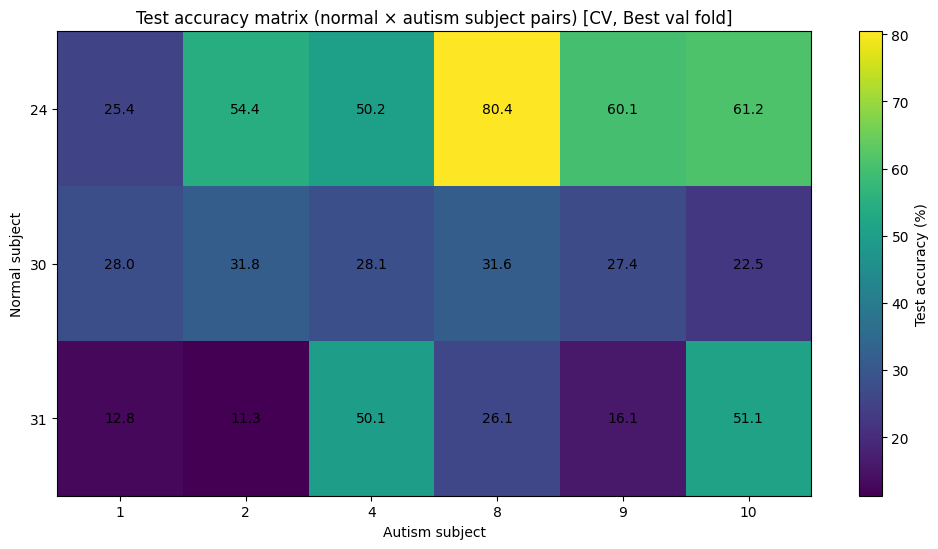

autism_subject,1,2,4,8,9,10
norm_subject,,,,,,
24,25.45,54.39,50.22,80.43,60.10,61.24
30,27.99,31.80,28.14,31.63,27.36,22.53
31,12.77,11.27,50.07,26.05,16.13,51.11


In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
RESULTS_CV_MAX_CSV = "pair_results_cv_max.csv"
# Load
df_cv = pd.read_csv(RESULTS_CV_MAX_CSV)

# Keep only successful runs
df_ok_cv = df_cv[(df_cv["status"] == "ok") & (df_cv["test_acc"].notna())].copy()

# Use your subject lists (or infer from df)
normal_subjects_cv = sorted(df_ok_cv["norm_subject"].unique().tolist())
autism_subjects_cv = sorted(df_ok_cv["autism_subject"].unique().tolist())

# Pivot into matrix (values in %)
mat_cv = df_ok_cv.pivot_table(
    index="norm_subject",
    columns="autism_subject",
    values="test_acc",
    aggfunc="mean"
) * 100.0

# Ensure consistent order
mat_cv = mat_cv.reindex(index=normal_subjects_cv, columns=autism_subjects_cv)

# ---- Plot as heatmap (matplotlib only) ----
plt.figure(figsize=(1.2*len(autism_subjects_cv) + 3, 1.2*len(normal_subjects_cv) + 2))
im_cv = plt.imshow(mat_cv.values, aspect="auto")  # no explicit colors
plt.colorbar(im_cv, label="Test accuracy (%)")

plt.xticks(ticks=np.arange(len(autism_subjects_cv)), labels=autism_subjects_cv)
plt.yticks(ticks=np.arange(len(normal_subjects_cv)), labels=normal_subjects_cv)
plt.xlabel("Autism subject")
plt.ylabel("Normal subject")
plt.title("Test accuracy matrix (normal × autism subject pairs) [CV, Best val fold]")

# Annotate each cell with the number (or NA)
for i in range(mat_cv.shape[0]):
    for j in range(mat_cv.shape[1]):
        val = mat_cv.values[i, j]
        txt = "NA" if np.isnan(val) else f"{val:.1f}"
        plt.text(j, i, txt, ha="center", va="center")

plt.tight_layout()
plt.show()

display(mat_cv)
